INFO:__main__:Loading model from malayalam_dataset/best_model_13_0.0271.keras
INFO:__main__:Loading class encodings from malayalam_dataset/encodings.json
INFO:__main__:Model loaded successfully!
INFO:__main__:Consonant classes: 54
INFO:__main__:Vowel classes: 13
INFO:__main__:Loading class encodings from malayalam_dataset/encodings.json
INFO:__main__:Model loaded successfully!
INFO:__main__:Consonant classes: 54
INFO:__main__:Vowel classes: 13


✅ Model loaded successfully!

🔍 Predicting 9 images:
------------------------------------------------------------
Image: U0D1A__NONE__Manjari-Regular__aug18.png
  Prediction: ച
  Consonant: ച (conf: 1.000)
  Vowel: NONE (conf: 1.000)
Image: U0D1A__NONE__Manjari-Regular__aug18.png
  Prediction: ച
  Consonant: ച (conf: 1.000)
  Vowel: NONE (conf: 1.000)


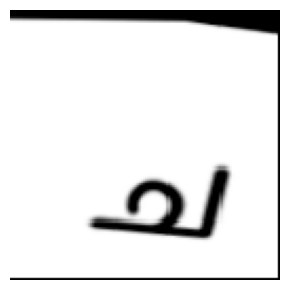

Image: WhatsApp Image 2025-09-22 at 14.42.59_5e461add.jpg
  Prediction: VOWEL_എ
  Consonant: VOWEL_എ (conf: 0.961)
  Vowel: NONE (conf: 1.000)


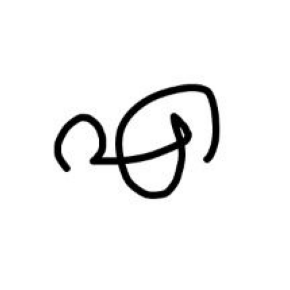

Image: WhatsApp Image 2025-09-22 at 14.43.11_f0309168.jpg
  Prediction: ങ
  Consonant: ങ (conf: 0.770)
  Vowel: NONE (conf: 1.000)


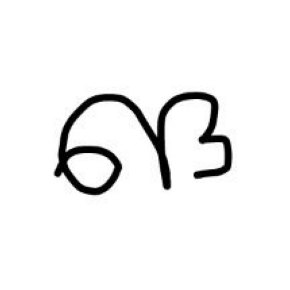

Image: WhatsApp Image 2025-09-22 at 14.48.47_0ea477cd.jpg
  Prediction: ദ
  Consonant: ദ (conf: 0.554)
  Vowel: NONE (conf: 0.985)


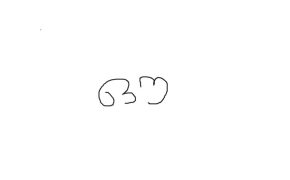

Image: WhatsApp Image 2025-09-22 at 14.49.23_65eed4f5.jpg
  Prediction: ക+ീ
  Consonant: ക (conf: 0.906)
  Vowel: ീ (conf: 1.000)


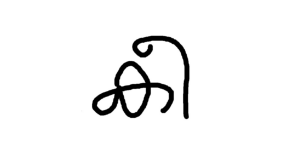

Image: WhatsApp Image 2025-09-22 at 14.49.45_ab73710c.jpg
  Prediction: ഴ
  Consonant: ഴ (conf: 0.694)
  Vowel: NONE (conf: 1.000)


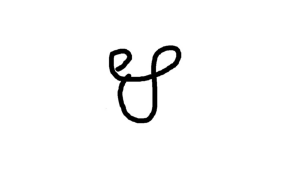

Image: WhatsApp Image 2025-09-22 at 14.50.38_a4b6c240.jpg
  Prediction: ഡ
  Consonant: ഡ (conf: 0.441)
  Vowel: NONE (conf: 0.889)


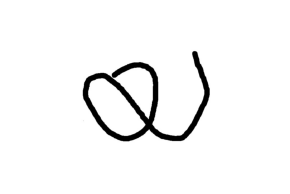

Image: WhatsApp Image 2025-09-22 at 14.51.03_95e68890.jpg
  Prediction: റ
  Consonant: റ (conf: 0.998)
  Vowel: NONE (conf: 1.000)


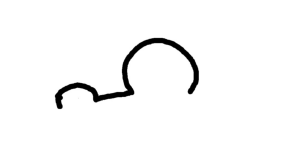

Image: WhatsApp Image 2025-09-22 at 14.51.32_89a33ad5.jpg
  Prediction: ഥ
  Consonant: ഥ (conf: 0.940)
  Vowel: NONE (conf: 1.000)


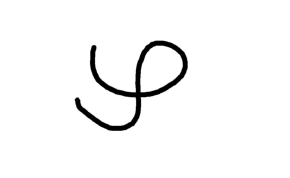


📋 Model Information:
  Consonant classes: 54
  Vowel classes: 13
  Input size: 128x128 grayscale


In [25]:
"""
Malayalam OCR Model Inference Script

This script demonstrates how to load and use the trained Malayalam OCR model
for inference on new images.

Author: Generated for Malayalam OCR project
Date: September 2025
"""

import os
import json
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import logging
import matplotlib.pyplot as plt

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

class MalayalamOCRModel:
    """
    Malayalam OCR model wrapper for easy inference
    """
    
    def __init__(self, model_path, encodings_path, img_size=128):
        """
        Initialize the Malayalam OCR model
        
        Args:
            model_path (str): Path to the trained .keras model file
            encodings_path (str): Path to encodings.json saved during training (required)
            img_size (int): Image size expected by model (default: 128)
        """
        self.img_size = img_size
        self.model_path = model_path
        self.encodings_path = encodings_path
        
        if not self.encodings_path or not os.path.exists(self.encodings_path):
            raise FileNotFoundError(
                f"encodings.json not found at {self.encodings_path}. This file is required to decode predictions."
            )
        
        # Load model
        logger.info(f"Loading model from {model_path}")
        self.model = tf.keras.models.load_model(model_path)
        
        # Recreate label encoders from training data
        self._setup_label_encoders()
        
        # Optional: validate output head sizes vs encodings length when possible
        try:
            outputs = self.model.outputs if hasattr(self.model, 'outputs') else self.model.output
            if isinstance(outputs, (list, tuple)) and len(outputs) >= 2:
                cons_dim = int(outputs[0].shape[-1])
                vow_dim = int(outputs[1].shape[-1])
                if cons_dim != len(self.le_consonant.classes_):
                    raise ValueError(
                        f"Model consonant head dim {cons_dim} != encodings consonant classes {len(self.le_consonant.classes_)}"
                    )
                if vow_dim != len(self.le_vowel.classes_):
                    raise ValueError(
                        f"Model vowel head dim {vow_dim} != encodings vowel classes {len(self.le_vowel.classes_)}"
                    )
        except Exception as e:
            # Log only; some models may not expose output shapes as expected
            logger.warning(f"Validation of output dims vs encodings skipped/failed: {e}")
        
        logger.info("Model loaded successfully!")
        logger.info(f"Consonant classes: {len(self.le_consonant.classes_)}")
        logger.info(f"Vowel classes: {len(self.le_vowel.classes_)}")
    
    def _setup_label_encoders(self):
        """Recreate label encoders strictly from encodings.json"""
        self.le_consonant = LabelEncoder()
        self.le_vowel = LabelEncoder()

        logger.info(f"Loading class encodings from {self.encodings_path}")
        with open(self.encodings_path, "r", encoding="utf-8") as f:
            enc = json.load(f)
        cons_classes = enc.get("consonant_classes")
        vow_classes = enc.get("vowel_classes")
        if not cons_classes or not vow_classes:
            raise ValueError("encodings.json missing required keys: 'consonant_classes' and 'vowel_classes'")
        # Set classes_ directly for decoding; also fit encoders minimally for API compat
        self.le_consonant.classes_ = np.array(cons_classes, dtype=object)
        self.le_vowel.classes_ = np.array(vow_classes, dtype=object)

        # Create inverse mappings for decoding predictions
        self.inv_consonant = {i: c for i, c in enumerate(self.le_consonant.classes_)}
        self.inv_vowel = {i: v for i, v in enumerate(self.le_vowel.classes_)}
    
    def preprocess_image(self, image_path_or_array):
        """
        Preprocess an image for model inference
        
        Args:
            image_path_or_array: Either a file path (str) or numpy array
            
        Returns:
            np.ndarray: Preprocessed image ready for model
        """
        if isinstance(image_path_or_array, str):
            # Load image from file
            img = Image.open(image_path_or_array).convert('L')  # Convert to grayscale
            img = img.resize((self.img_size, self.img_size))
            img_array = np.array(img)
        else:
            # Assume it's already a numpy array
            img_array = image_path_or_array
            if len(img_array.shape) == 3:
                # Convert RGB to grayscale if needed
                img_array = np.dot(img_array[...,:3], [0.2989, 0.5870, 0.1140])
        
        # Normalize to [0, 1] and add batch dimension
        img_array = img_array.astype(np.float32) / 255.0
        img_array = np.expand_dims(img_array, axis=-1)  # Add channel dimension
        img_array = np.expand_dims(img_array, axis=0)   # Add batch dimension
        
        return img_array
    
    def predict(self, image_path_or_array, return_probabilities=False):
        """
        Predict Malayalam character from image
        
        Args:
            image_path_or_array: Image file path or numpy array
            return_probabilities (bool): If True, return prediction probabilities
            
        Returns:
            dict: Prediction results with consonant and vowel
        """
        # Preprocess image
        img_array = self.preprocess_image(image_path_or_array)
        
        # Get model predictions
        predictions = self.model.predict(img_array, verbose=0)
        
        # Get predicted classes
        cons_pred_idx = np.argmax(predictions["cons"][0])
        vow_pred_idx = np.argmax(predictions["vow"][0])
        
        # Decode predictions
        consonant = self.inv_consonant[cons_pred_idx]
        vowel = self.inv_vowel[vow_pred_idx]
        
        result = {
            "consonant": consonant,
            "vowel": vowel,
            "combined": f"{consonant}+{vowel}" if vowel != "NONE" else consonant
        }
        
        if return_probabilities:
            result["consonant_confidence"] = float(np.max(tf.nn.softmax(predictions["cons"][0])))
            result["vowel_confidence"] = float(np.max(tf.nn.softmax(predictions["vow"][0])))
            result["consonant_probabilities"] = tf.nn.softmax(predictions["cons"][0]).numpy()
            result["vowel_probabilities"] = tf.nn.softmax(predictions["vow"][0]).numpy()
        
        return result
    
    def predict_batch(self, image_paths_or_arrays, return_probabilities=False):
        """
        Predict multiple images at once
        
        Args:
            image_paths_or_arrays: List of image paths or arrays
            return_probabilities (bool): If True, return prediction probabilities
            
        Returns:
            list: List of prediction results
        """
        results = []
        for img in image_paths_or_arrays:
            result = self.predict(img, return_probabilities)
            results.append(result)
        return results


def main():
    """
    Example usage of the Malayalam OCR model
    """
    # Paths - adjust these for your setup
    model_path = "malayalam_dataset/best_model_13_0.0271.keras"  # Best model
    encodings_path = "malayalam_dataset/encodings.json"
    
    # Check if files exist
    if not os.path.exists(model_path):
        print(f"❌ Model file not found: {model_path}")
        print("Available models:")
        model_dir = os.path.dirname(model_path)
        if os.path.exists(model_dir):
            for f in os.listdir(model_dir):
                if f.endswith('.keras'):
                    print(f"  - {f}")
        return
    
    if not os.path.exists(encodings_path):
        print(f"❌ Encodings file not found: {encodings_path}")
        return
    
    # Initialize model
    try:
        ocr_model = MalayalamOCRModel(model_path, encodings_path)
        print("✅ Model loaded successfully!")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return
    
    # Predict for every image in the directory (no sampling)
    image_dir = "test"
    if os.path.exists(image_dir):
        # Get all image files (common extensions)
        image_files = sorted(
            [f for f in os.listdir(image_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        )
        print(f"\n🔍 Predicting {len(image_files)} images:")
        print("-" * 60)
        
        if not image_files:
            print("No images found with extensions .png, .jpg, .jpeg")
            return
        
        for img_name in image_files:
            img_path = os.path.join(image_dir, img_name)
            try:
                result = ocr_model.predict(img_path, return_probabilities=True)
                print(f"Image: {img_name}")
                print(f"  Prediction: {result['combined']}")
                print(f"  Consonant: {result['consonant']} (conf: {result['consonant_confidence']:.3f})")
                print(f"  Vowel: {result['vowel']} (conf: {result['vowel_confidence']:.3f})")
                
                # Show image preview with result
                img_disp = Image.open(img_path)
                plt.figure(figsize=(3, 3))
                plt.imshow(img_disp, cmap='gray')
                plt.axis('off')
                plt.tight_layout()
                plt.show()
                
            except Exception as e:
                print(f"  ❌ Error predicting {img_name}: {e}")
    else:
        print(f"\n📁 No test images found in {image_dir}")
        print("To test with your own images:")
        print("  result = ocr_model.predict('path/to/your/image.png')")
        print("  print(result)")
    
    # Show model info
    print("\n📋 Model Information:")
    print(f"  Consonant classes: {len(ocr_model.le_consonant.classes_)}")
    print(f"  Vowel classes: {len(ocr_model.le_vowel.classes_)}")
    print(f"  Input size: {ocr_model.img_size}x{ocr_model.img_size} grayscale")

if __name__ == "__main__":
    main()